In [1]:
a=2
print(a)

2


In [3]:
b=4.5
print(b)

4.5


=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

=== First 5 Rows ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4 

<Figure size 1500x1000 with 0 Axes>

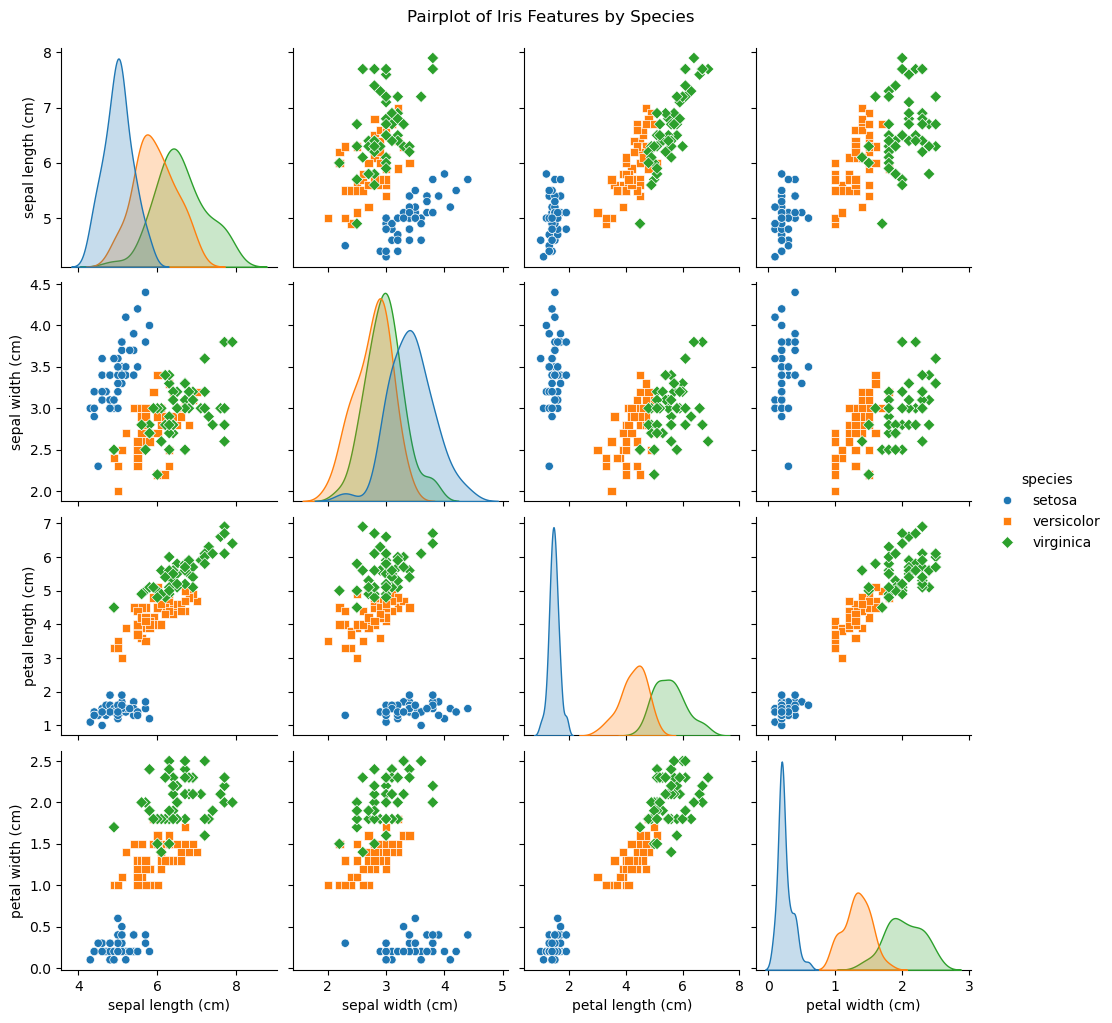

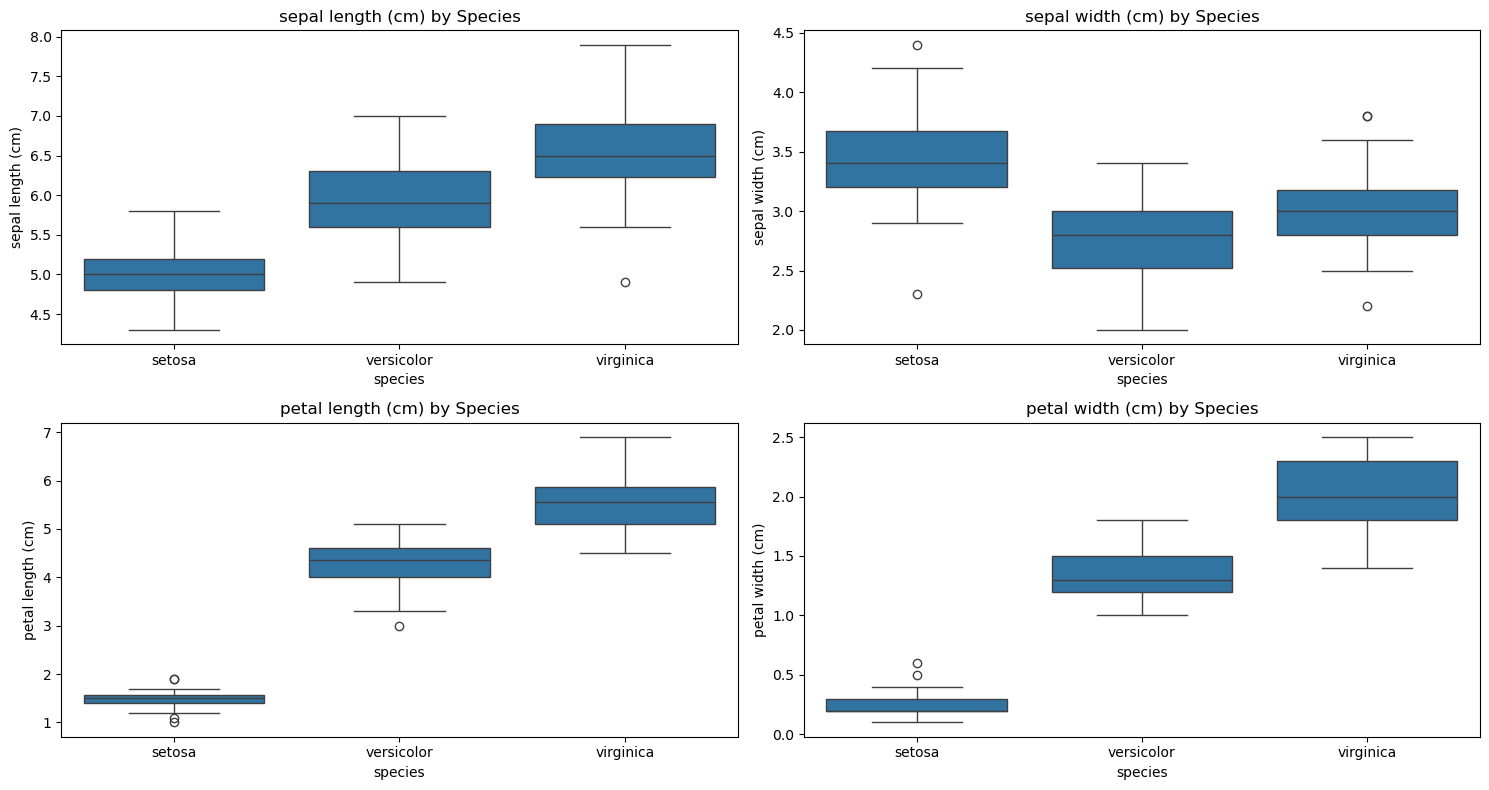

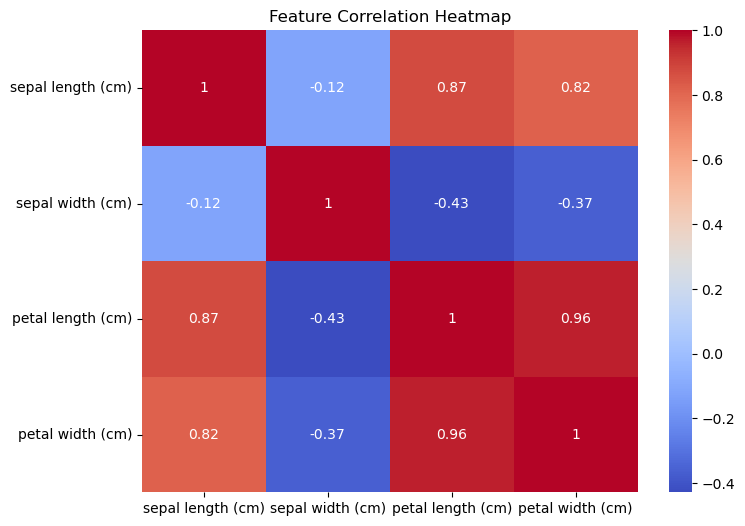


=== K-Nearest Neighbors ===
Accuracy: 0.9333

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


=== Support Vector Machine ===
Accuracy: 0.9667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97     

F:\anacondaa\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


AttributeError: This 'SVC' has no attribute 'predict_proba'

In [5]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Create a DataFrame for better visualization
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['species'] = y
iris_df['species'] = iris_df['species'].map({0: target_names[0], 1: target_names[1], 2: target_names[2]})

# Exploratory Data Analysis (EDA)
print("=== Dataset Information ===")
print(iris_df.info())
print("\n=== First 5 Rows ===")
print(iris_df.head())
print("\n=== Summary Statistics ===")
print(iris_df.describe())
print("\n=== Class Distribution ===")
print(iris_df['species'].value_counts())

# Visualize the data
plt.figure(figsize=(15, 10))

# Pairplot
sns.pairplot(iris_df, hue='species', markers=['o', 's', 'D'])
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()

# Boxplot for each feature
plt.figure(figsize=(15, 8))
for i, feature in enumerate(feature_names):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='species', y=feature, data=iris_df)
    plt.title(f'{feature} by Species')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(iris_df.drop('species', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Data Preprocessing
# Split into features and target
X = iris_df.drop('species', axis=1)
y = iris_df['species']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training and Evaluation
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'classification_report': cr
    }
    
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(cr)

# Find the best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']
print(f"\nBest Model: {best_model_name} with accuracy {results[best_model_name]['accuracy']:.4f}")

# Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(8, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title('Feature Importance')
    plt.show()

# Make predictions on new data
def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    # Create a numpy array from the input
    new_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    
    # Scale the features
    new_data_scaled = scaler.transform(new_data)
    
    # Make prediction
    prediction = best_model.predict(new_data_scaled)
    probabilities = best_model.predict_proba(new_data_scaled)[0]
    
    print("\n=== Prediction ===")
    print(f"Predicted Species: {prediction[0]}")
    print("\n=== Probabilities ===")
    for i, species in enumerate(target_names):
        print(f"{species}: {probabilities[i]:.4f}")

# Example prediction
predict_iris(5.1, 3.5, 1.4, 0.2)  # Should predict setosa
predict_iris(6.3, 2.5, 5.0, 1.9)  # Should predict virginica

# Save the model (optional)
#import joblib
#joblib.dump(best_model, 'iris_classifier.pkl')
#joblib.dump(scaler, 'iris_scaler.pkl')

#print("\nModel and scaler saved to disk.")

In [7]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features (sepal length, sepal width, petal length, petal width)
y = iris.target  # Target (0=setosa, 1=versicolor, 2=virginica)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model (K-Nearest Neighbors)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Make predictions on test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Example prediction
def predict_flower(sepal_length, sepal_width, petal_length, petal_width):
    prediction = model.predict([[sepal_length, sepal_width, petal_length, petal_width]])
    species = ['setosa', 'versicolor', 'virginica'][prediction[0]]
    print(f"Predicted species: {species}")

# Test predictions
predict_flower(5.1, 3.5, 1.4, 0.2)  # Should predict setosa
predict_flower(6.0, 2.7, 5.1, 1.6)  # Should predict virginica

Model Accuracy: 1.00
Predicted species: setosa
Predicted species: virginica


In [9]:
# Save the model (optional)
import joblib
joblib.dump(best_model, 'iris_classifier.pkl')
joblib.dump(scaler, 'iris_scaler.pkl')

print("\nModel and scaler saved to disk.")


Model and scaler saved to disk.
